In [1]:
JSON_FILE_PATH = "./json/front/A1-A3.json"

In [2]:
from src.json_pose import PoseData3D
import src.kpt_special_data as kpt_special_data
import src.draw_plot as draw_plot
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
data = PoseData3D(JSON_FILE_PATH)
json_pth = Path(JSON_FILE_PATH)
frame_idx = 0

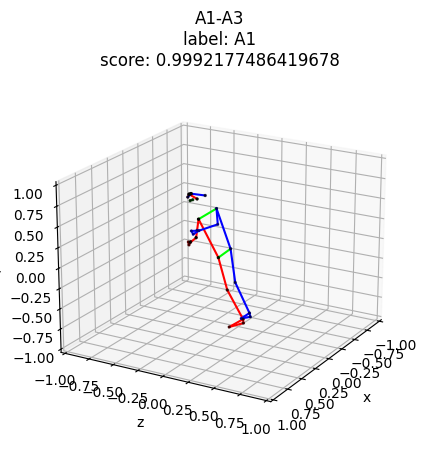

In [4]:
# 取得所需資料
left, center, right = data.get_pos_connection_list(
    0, 0, kpt_special_data.blazepose_connection, True
)
pos = data.get_pos_list(frame_idx, 0, True)
labels = data.to_label_list()

ax = plt.subplot(projection="3d")
ax.set_title(
    f"{json_pth.stem}\nlabel: {labels[frame_idx]}\nscore: {data.get_kpt_score(frame_idx, 0)}"
)

# 繪製線條
ax = draw_plot.get_line_plot(left, is_3d=True, color="#f00", ax=ax)
ax = draw_plot.get_line_plot(center, is_3d=True, color="#0f0", ax=ax)
ax = draw_plot.get_line_plot(right, is_3d=True, color="#00f", ax=ax)

# 繪製點
ax = draw_plot.get_dots_in_scatter(
    pos, data_range=[-1, 1], is_3d=True, dot_size=2, color="#000", ax=ax
)
# 設置視角
ax.view_init(elev=20, azim=30, roll=0)

plt.show()